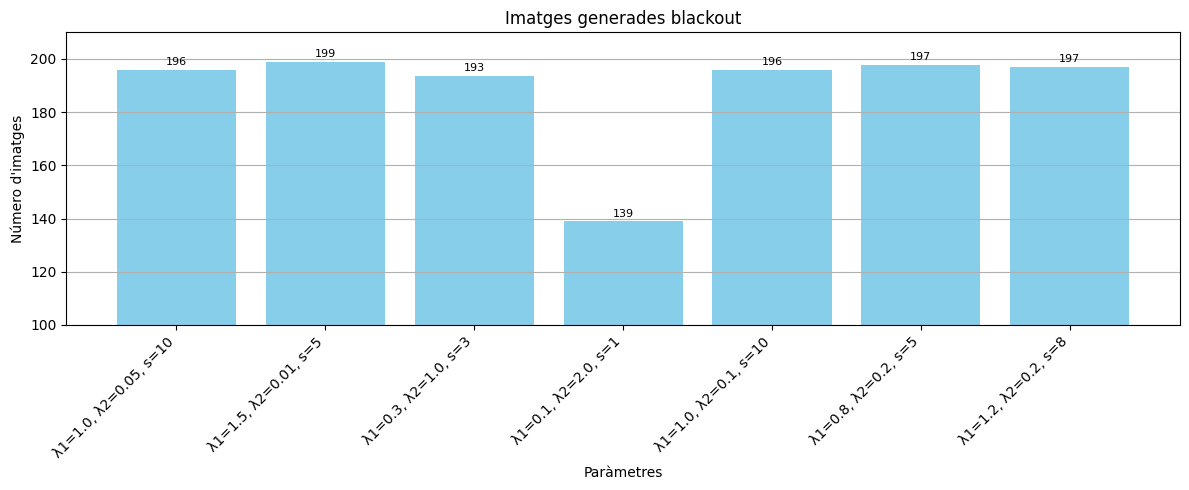

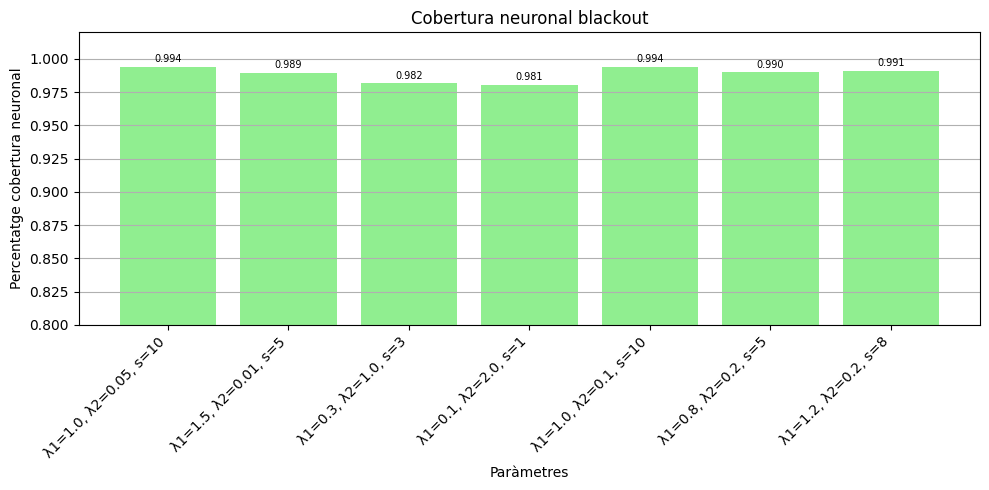

In [ ]:
from collections import defaultdict
import os
import zipfile
import matplotlib.pyplot as plt
import re

def parse_lambda(s):
    s = s.replace('-', '.')
    if s.startswith('0') and len(s) > 1:
        return float("0." + s[1:])
    else:
        return float(s)

def format_label(param_string):
    parts = param_string.split("__")[1].split("_")
    lam1 = parse_lambda(parts[0])
    lam2 = parse_lambda(parts[1])
    s = int(parts[2])
    return f"λ1={lam1}, λ2={lam2}, s={s}"

base_keys_order = [
    "1_005_10_0", "1-5_001_5_0",
    "03_1_3_0", "01_2_1_0",
    "1_01_10_0", "08_02_5_0", "1-2_02_8_0"
]

base_path = "/content/TFG/MNIST/Resultats/Resultats_configuracions"

coverage_values = defaultdict(list)
zipcount_values = defaultdict(list)

for prefix in ["0", "1", "2"]:
    for base_key in base_keys_order:
        full_key = f"{prefix}__{base_key}"
        txt_path = os.path.join(base_path, f"output_MNIST_blackout{full_key}.txt")
        zip_path = os.path.join(base_path, f"generated_inputs_MNIST_blackout{full_key}.zip")

        if os.path.isfile(txt_path):
            with open(txt_path, 'r') as f:
                lines = f.readlines()
                for line in reversed(lines):
                    line = re.sub(r'\x1b\[[0-9;]*m', '', line)
                    if "averaged covered neurons" in line:
                        cov = float(line.strip().split()[-1])
                        coverage_values[base_key].append(cov)
                        break

        if os.path.isfile(zip_path):
            with zipfile.ZipFile(zip_path, 'r') as zipf:
                zipcount_values[base_key].append(len(zipf.namelist()))

import numpy as np
coverage_means = [np.mean(coverage_values[k]) for k in base_keys_order]
zipcount_means = [np.mean(zipcount_values[k]) for k in base_keys_order]
labels = [format_label(f"0__{k}") for k in base_keys_order]

plt.figure(figsize=(12, 5))
bars = plt.bar(labels, zipcount_means, color='skyblue')
plt.xlabel("Paràmetres")
plt.ylabel("Número d'imatges")
plt.title("Imatges generades blackout")
plt.xticks(rotation=45, ha='right')
plt.ylim(100, 210)

for bar, value in zip(bars, zipcount_means):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1, f'{int(value)}',
             ha='center', va='bottom', fontsize=8, color='black')

plt.grid(axis='y')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
bars = plt.bar(labels, coverage_means, color='lightgreen')
plt.xlabel("Paràmetres")
plt.ylabel("Percentatge cobertura neuronal")
plt.title("Cobertura neuronal blackout")
plt.xticks(rotation=45, ha='right')
plt.ylim(0.8, 1.02)

for bar, value in zip(bars, coverage_means):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002, f'{value:.3f}',
             ha='center', va='bottom', fontsize=7, color='black')

plt.grid(axis='y')
plt.tight_layout()
plt.show()

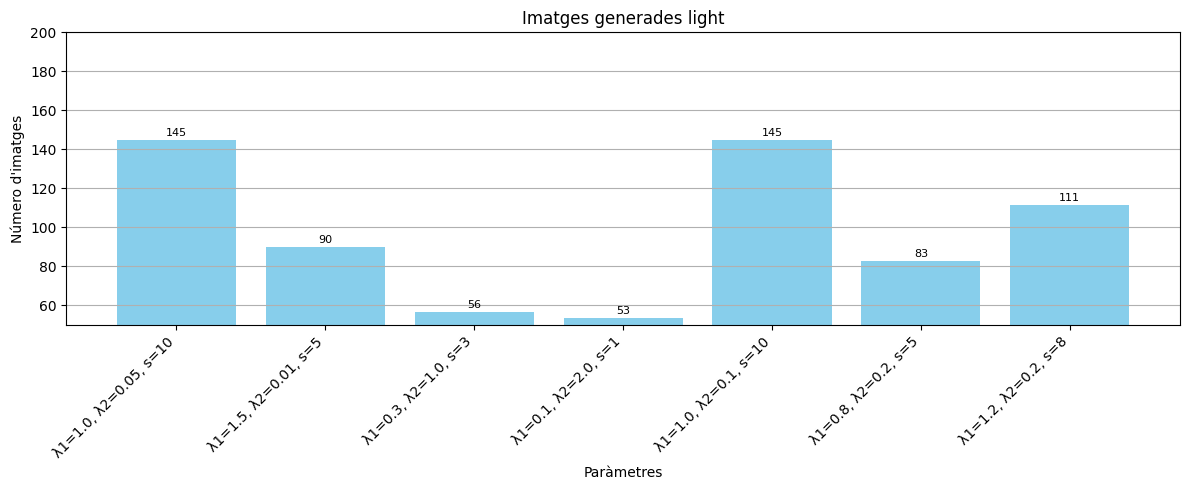

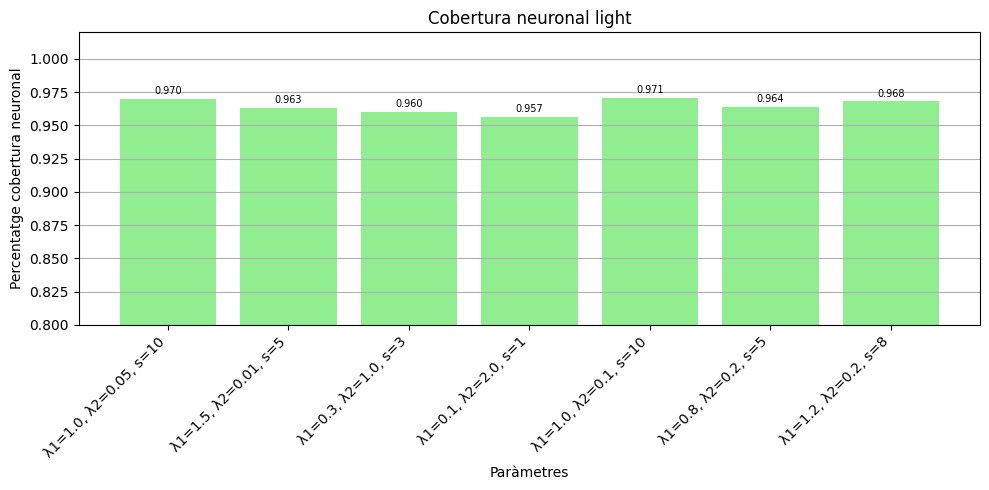

In [ ]:
from collections import defaultdict
import os
import zipfile
import matplotlib.pyplot as plt
import re

def parse_lambda(s):
    s = s.replace('-', '.')
    if s.startswith('0') and len(s) > 1:
        return float("0." + s[1:])
    else:
        return float(s)

def format_label(param_string):
    parts = param_string.split("__")[1].split("_")
    lam1 = parse_lambda(parts[0])
    lam2 = parse_lambda(parts[1])
    s = int(parts[2])
    return f"λ1={lam1}, λ2={lam2}, s={s}"

base_keys_order = [
    "1_005_10_0", "1-5_001_5_0",
    "03_1_3_0", "01_2_1_0",
    "1_01_10_0", "08_02_5_0", "1-2_02_8_0"
]

base_path = "/content/TFG/MNIST/Resultats/Resultats_configuracions"

coverage_values = defaultdict(list)
zipcount_values = defaultdict(list)

for prefix in ["0", "1", "2"]:
    for base_key in base_keys_order:
        full_key = f"{prefix}__{base_key}"
        txt_path = os.path.join(base_path, f"output_MNIST_light{full_key}.txt")
        zip_path = os.path.join(base_path, f"generated_inputs_MNIST_light{full_key}.zip")

        if os.path.isfile(txt_path):
            with open(txt_path, 'r') as f:
                lines = f.readlines()
                for line in reversed(lines):
                    line = re.sub(r'\x1b\[[0-9;]*m', '', line)
                    if "averaged covered neurons" in line:
                        cov = float(line.strip().split()[-1])
                        coverage_values[base_key].append(cov)
                        break

        if os.path.isfile(zip_path):
            with zipfile.ZipFile(zip_path, 'r') as zipf:
                zipcount_values[base_key].append(len(zipf.namelist()))

import numpy as np
coverage_means = [np.mean(coverage_values[k]) for k in base_keys_order]
zipcount_means = [np.mean(zipcount_values[k]) for k in base_keys_order]
labels = [format_label(f"0__{k}") for k in base_keys_order]

plt.figure(figsize=(12, 5))
bars = plt.bar(labels, zipcount_means, color='skyblue')
plt.xlabel("Paràmetres")
plt.ylabel("Número d'imatges")
plt.title("Imatges generades light")
plt.xticks(rotation=45, ha='right')
plt.ylim(50, 200)

for bar, value in zip(bars, zipcount_means):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1, f'{int(value)}',
             ha='center', va='bottom', fontsize=8, color='black')

plt.grid(axis='y')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
bars = plt.bar(labels, coverage_means, color='lightgreen')
plt.xlabel("Paràmetres")
plt.ylabel("Percentatge cobertura neuronal")
plt.title("Cobertura neuronal light")
plt.xticks(rotation=45, ha='right')
plt.ylim(0.8, 1.02)

for bar, value in zip(bars, coverage_means):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002, f'{value:.3f}',
             ha='center', va='bottom', fontsize=7, color='black')

plt.grid(axis='y')
plt.tight_layout()
plt.show()

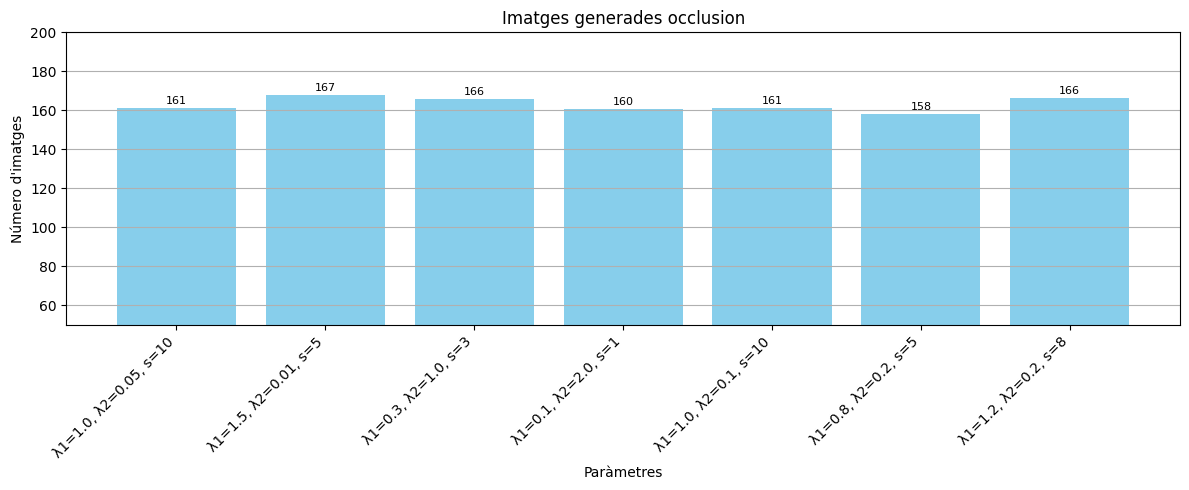

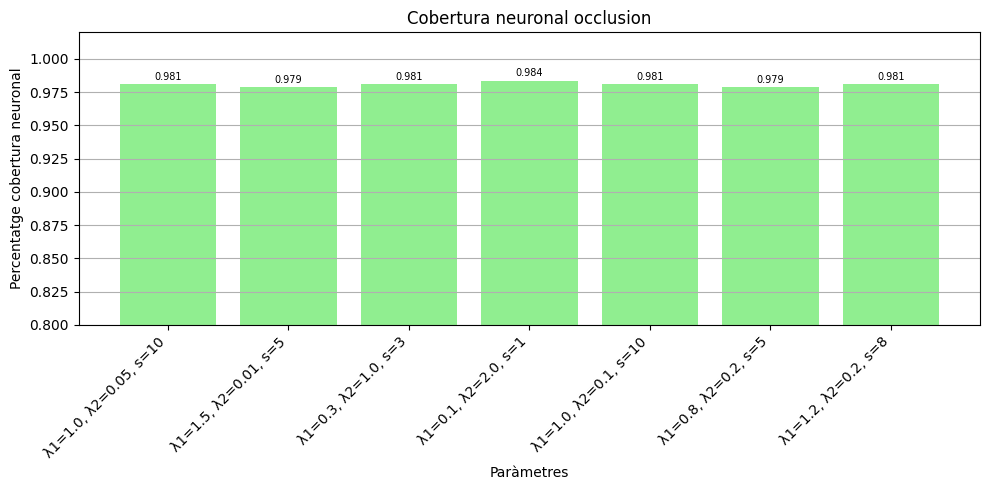

In [ ]:
from collections import defaultdict
import os
import zipfile
import matplotlib.pyplot as plt
import re


def parse_lambda(s):
    s = s.replace('-', '.')
    if s.startswith('0') and len(s) > 1:
        return float("0." + s[1:])
    else:
        return float(s)

def format_label(param_string):
    parts = param_string.split("__")[1].split("_")
    lam1 = parse_lambda(parts[0])
    lam2 = parse_lambda(parts[1])
    s = int(parts[2])
    return f"λ1={lam1}, λ2={lam2}, s={s}"

base_keys_order = [
    "1_005_10_0", "1-5_001_5_0",
    "03_1_3_0", "01_2_1_0",
    "1_01_10_0", "08_02_5_0", "1-2_02_8_0"
]

base_path = "/content/TFG/MNIST/Resultats/Resultats_configuracions"

coverage_values = defaultdict(list)
zipcount_values = defaultdict(list)

for prefix in ["0", "1", "2"]:
    for base_key in base_keys_order:
        full_key = f"{prefix}__{base_key}"
        txt_path = os.path.join(base_path, f"output_MNIST_occl{full_key}.txt")
        zip_path = os.path.join(base_path, f"generated_inputs_MNIST_occl{full_key}.zip")

        if os.path.isfile(txt_path):
            with open(txt_path, 'r') as f:
                lines = f.readlines()
                for line in reversed(lines):
                    line = re.sub(r'\x1b\[[0-9;]*m', '', line)
                    if "averaged covered neurons" in line:
                        cov = float(line.strip().split()[-1])
                        coverage_values[base_key].append(cov)
                        break

        if os.path.isfile(zip_path):
            with zipfile.ZipFile(zip_path, 'r') as zipf:
                zipcount_values[base_key].append(len(zipf.namelist()))

import numpy as np
coverage_means = [np.mean(coverage_values[k]) for k in base_keys_order]
zipcount_means = [np.mean(zipcount_values[k]) for k in base_keys_order]
labels = [format_label(f"0__{k}") for k in base_keys_order]

plt.figure(figsize=(12, 5))
bars = plt.bar(labels, zipcount_means, color='skyblue')
plt.xlabel("Paràmetres")
plt.ylabel("Número d'imatges")
plt.title("Imatges generades occlusion")
plt.xticks(rotation=45, ha='right')
plt.ylim(50, 200)

for bar, value in zip(bars, zipcount_means):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1, f'{int(value)}',
             ha='center', va='bottom', fontsize=8, color='black')

plt.grid(axis='y')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
bars = plt.bar(labels, coverage_means, color='lightgreen')
plt.xlabel("Paràmetres")
plt.ylabel("Percentatge cobertura neuronal")
plt.title("Cobertura neuronal occlusion")
plt.xticks(rotation=45, ha='right')
plt.ylim(0.8, 1.02)

for bar, value in zip(bars, coverage_means):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002, f'{value:.3f}',
             ha='center', va='bottom', fontsize=7, color='black')

plt.grid(axis='y')
plt.tight_layout()
plt.show()

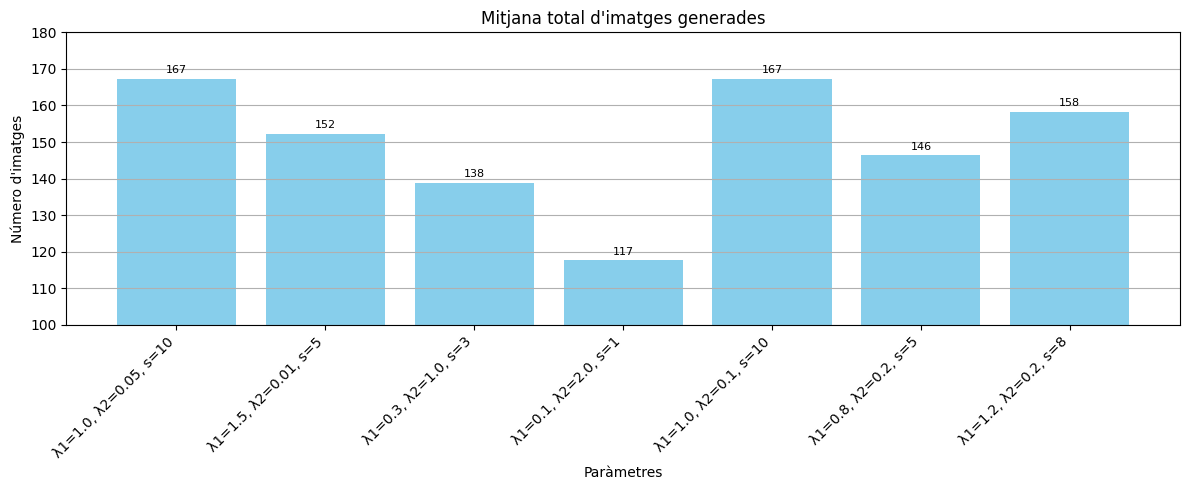

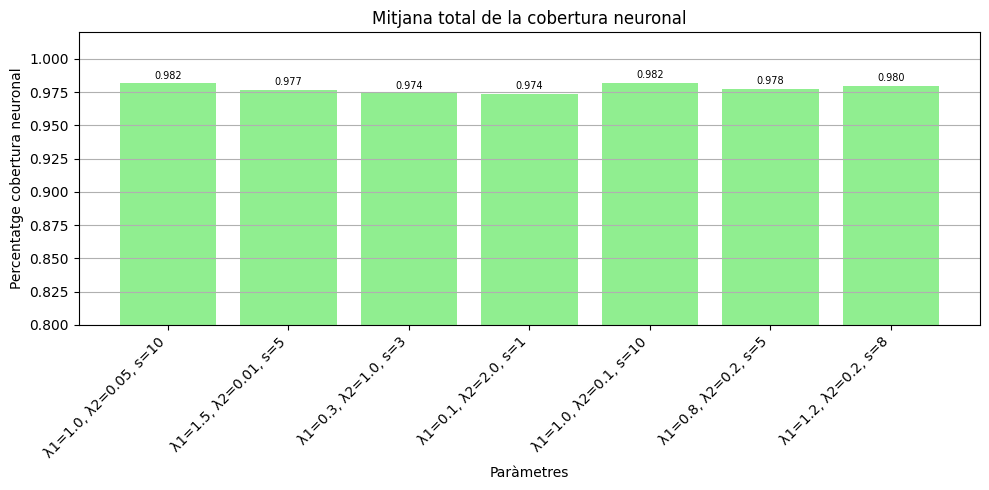

In [ ]:
from collections import defaultdict
import os
import zipfile
import matplotlib.pyplot as plt
import re

def parse_lambda(s):
    s = s.replace('-', '.')
    if s.startswith('0') and len(s) > 1:
        return float("0." + s[1:])
    else:
        return float(s)

def format_label(param_string):
    parts = param_string.split("__")[1].split("_")
    lam1 = parse_lambda(parts[0])
    lam2 = parse_lambda(parts[1])
    s = int(parts[2])
    return f"λ1={lam1}, λ2={lam2}, s={s}"

base_keys_order = [
    "1_005_10_0", "1-5_001_5_0",
    "03_1_3_0", "01_2_1_0",
    "1_01_10_0", "08_02_5_0", "1-2_02_8_0"
]

base_path = "/content/TFG/MNIST/Resultats/Resultats_configuracions"

modes = ["blackout", "light", "occl"]
prefixes = ["0", "1", "2"]

coverage_values = {k: [] for k in base_keys_order}
zipcount_values = {k: [] for k in base_keys_order}

for mode in modes:
    for prefix in prefixes:
        for base_key in base_keys_order:
            full_key = f"{prefix}__{base_key}"

            txt_path = os.path.join(base_path, f"output_MNIST_{mode}{full_key}.txt")
            zip_path = os.path.join(base_path, f"generated_inputs_MNIST_{mode}{full_key}.zip")

            if os.path.isfile(txt_path):
                with open(txt_path, 'r') as f:
                    lines = f.readlines()
                    for line in reversed(lines):
                        line = re.sub(r'\x1b\[[0-9;]*m', '', line)
                        if "averaged covered neurons" in line:
                            cov = float(line.strip().split()[-1])
                            coverage_values[base_key].append(cov)
                            break

            if os.path.isfile(zip_path):
                with zipfile.ZipFile(zip_path, 'r') as zipf:
                    zipcount_values[base_key].append(len(zipf.namelist()))

import numpy as np
coverage_means = [np.mean(coverage_values[k]) for k in base_keys_order]
zipcount_means = [np.mean(zipcount_values[k]) for k in base_keys_order]
labels = [format_label(f"0__{k}") for k in base_keys_order]

plt.figure(figsize=(12, 5))
bars = plt.bar(labels, zipcount_means, color='skyblue')
plt.xlabel("Paràmetres")
plt.ylabel("Número d'imatges")
plt.title("Mitjana total d'imatges generades")
plt.xticks(rotation=45, ha='right')
plt.ylim(100, 180)

for bar, value in zip(bars, zipcount_means):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1, f'{int(value)}',
             ha='center', va='bottom', fontsize=8, color='black')

plt.grid(axis='y')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
bars = plt.bar(labels, coverage_means, color='lightgreen')
plt.xlabel("Paràmetres")
plt.ylabel("Percentatge cobertura neuronal")
plt.title("Mitjana total de la cobertura neuronal")
plt.xticks(rotation=45, ha='right')
plt.ylim(0.8, 1.02)

for bar, value in zip(bars, coverage_means):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002, f'{value:.3f}',
             ha='center', va='bottom', fontsize=7, color='black')

plt.grid(axis='y')
plt.tight_layout()
plt.show()

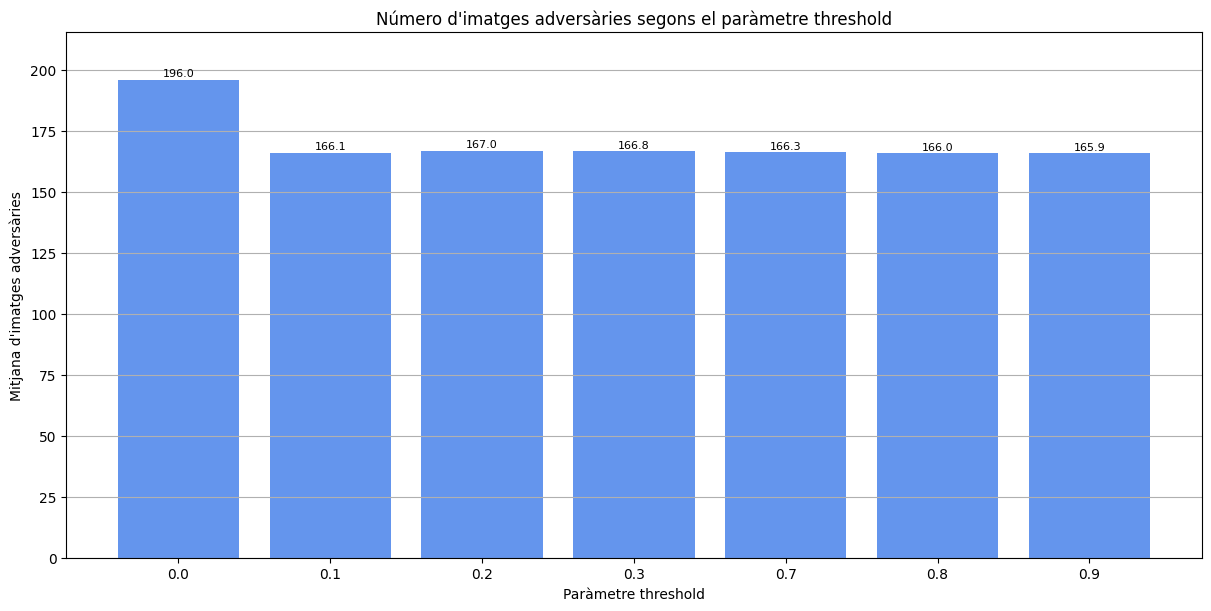

In [ ]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import zipfile

base_path = "/content/TFG/MNIST/Resultats/Resultats_llindar"  
modes = ["blackout", "light", "occl"]
prefixes = ["0", "1", "2"]
base_key_base = "1_01_10"
last_params = ["0", "09", "08", "07","03","02", "01"]

coverage_by_last_param = defaultdict(list)
zipcount_by_last_param = defaultdict(list)

for mode in modes:
    for prefix in prefixes:
        for last_param in last_params:
            full_key = f"{prefix}__{base_key_base}_{last_param}"

            txt_path = os.path.join(base_path, f"output_MNIST_{mode}{full_key}.txt")
            if os.path.isfile(txt_path):
                with open(txt_path, 'r') as f:
                    lines = f.readlines()
                    for line in reversed(lines):
                        line = re.sub(r'\x1b\[[0-9;]*m', '', line)
                        if "averaged covered neurons" in line:
                            cov = float(line.strip().split()[-1])
                            coverage_by_last_param[last_param].append(cov)
                            break

            zip_path = os.path.join(base_path, f"generated_inputs_MNIST_{mode}{full_key}.zip")
            if os.path.isfile(zip_path):
                with zipfile.ZipFile(zip_path, 'r') as zipf:
                    zipcount_by_last_param[last_param].append(len(zipf.namelist()))

labels = sorted(zipcount_by_last_param.keys())
float_labels = [int(l) / 10 for l in labels]
averages_zipcount = [np.mean(zipcount_by_last_param[k]) for k in labels]

fig, ax = plt.subplots(figsize=(12, 6), constrained_layout=True)
bars = ax.bar([str(l) for l in float_labels], averages_zipcount, color='cornflowerblue')
ax.set_xlabel("Paràmetre threshold")
ax.set_ylabel("Mitjana d'imatges adversàries")
ax.set_title("Número d'imatges adversàries segons el paràmetre threshold")
ax.set_ylim(0, max(averages_zipcount)*1.1)
ax.grid(axis='y')

for bar, value in zip(bars, averages_zipcount):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{value:.1f}", ha='center', va='bottom', fontsize=8)

plt.show()


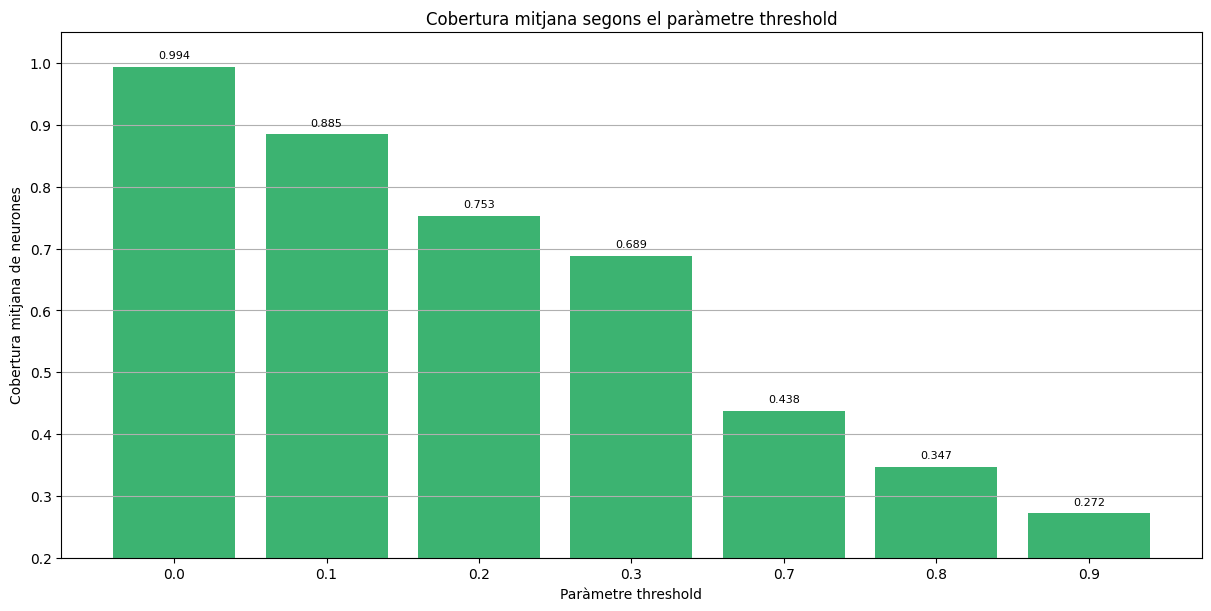

In [ ]:
labels = sorted(coverage_by_last_param.keys())
float_labels = [int(l) / 10 for l in labels]  
averages = [np.mean(coverage_by_last_param[k]) for k in labels]

fig, ax = plt.subplots(figsize=(12, 6), constrained_layout=True)
bars = ax.bar([str(l) for l in float_labels], averages, color='mediumseagreen')
ax.set_xlabel("Paràmetre threshold")
ax.set_ylabel("Cobertura mitjana de neurones")
ax.set_title("Cobertura mitjana segons el paràmetre threshold")
ax.set_ylim(0.2, 1.05)
ax.grid(axis='y')

for bar, value in zip(bars, averages):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{value:.3f}", ha='center', va='bottom', fontsize=8)

plt.show()
